# THUISBATTERIJ PLUS DYNAMISCH ENERGIECONTRACT EN POSTCODEROOS DEELNAME

Onderzoeksvraag:
Wat is de terugverdientijd van een thuisbatterij bij verschillende contracten.
- vast contract
- dynamisch contract
- dynamisch contract + postcoderoos voordeel

Reading file into a pandas table: /Users/felixdonkers/Library/Mobile Documents/com~apple~CloudDocs/my_python_projects/misc_projects/thuisbatterij/energieverbruik/P1e-processed.csv
Reading file into a pandas table: /Users/felixdonkers/Library/Mobile Documents/com~apple~CloudDocs/my_python_projects/misc_projects/thuisbatterij/energieprijzen/dynamische_stroomprijzen_jeroenpuntnl_GreenChoice_2025-07-01_2026-07-01_all_in.csv
Rows in verbruikTable: 365, elements per row: 101


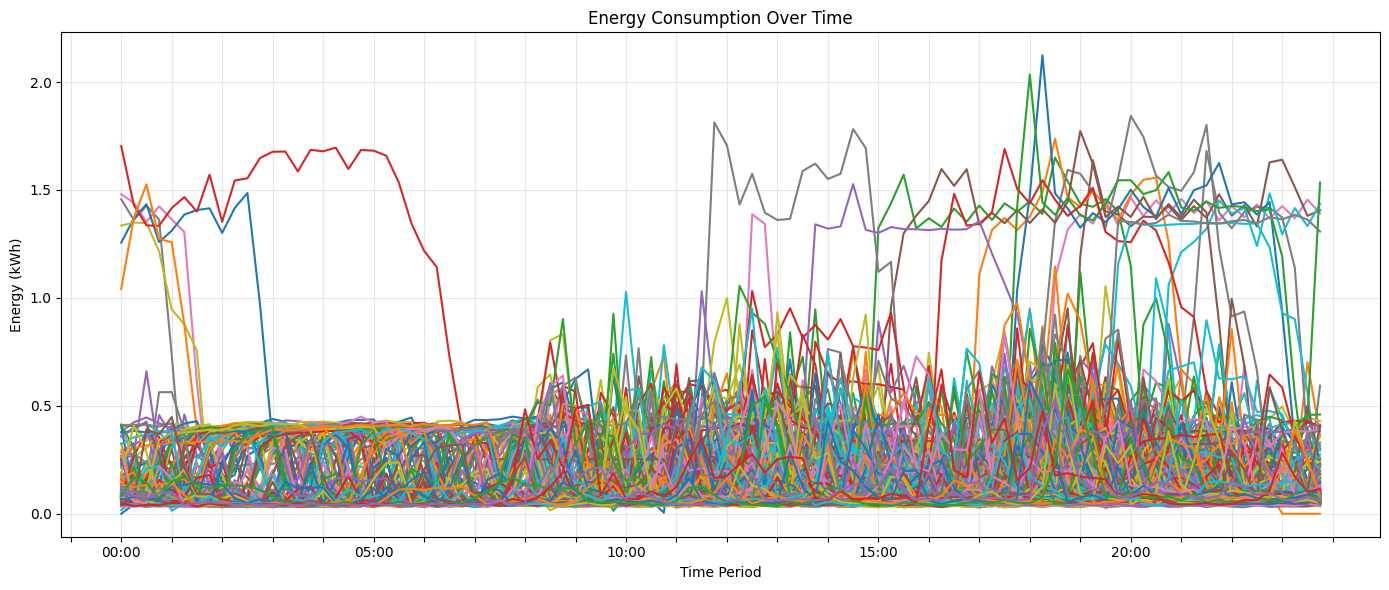

Rows in prijzenTable: 365, elements per row: 101


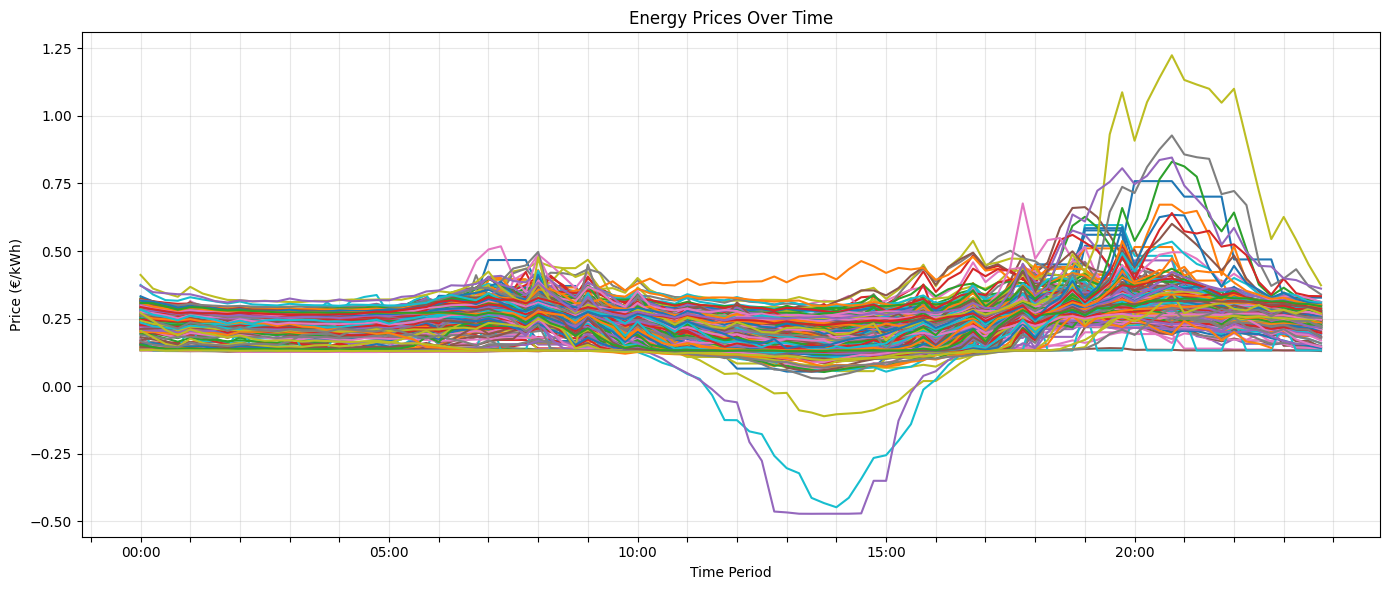

In [ ]:
# INLEZEN DATA BESTANDEN EN CONSTANTES

from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import pandas as pd

ENERGY_CONSUMPTION_CSV = (Path.cwd() / "../energieverbruik/P1e-processed.csv").resolve()
ENERGY_PRICES_CSV = (Path.cwd() / "../energieprijzen/dynamische_stroomprijzen_jeroenpuntnl_GreenChoice_2025-07-01_2026-07-01_all_in.csv").resolve()

EXCLUDED_COLUMNS = {"date", "total", "minimum", "average", "maximum"}

KWH_PRICE = 0.27  # €/kWh
BATTERY_CAPACITY = 6 # kWh
CHARGING_POWER = .8 # kW
RTE = 0.9  # round-trip efficiency
BATTERY_COSTS_PER_KWH = 500  # euro per kWh
BATTERY_PRICE = 250 + BATTERY_COSTS_PER_KWH * BATTERY_CAPACITY

def read_csv_to_dataframe(csv_path: Path) -> pd.DataFrame:
    print(f"Reading file into a pandas table: {csv_path}")
    return pd.read_csv(csv_path, encoding="utf-8")

def plot_dataframe(df: pd.DataFrame, title: str, xlabel: str, ylabel: str):
    numeric_columns = [col for col in df.columns if col.lower() not in EXCLUDED_COLUMNS]
    fig, ax = plt.subplots(figsize=(14, 6))
    df[numeric_columns].T.plot(ax=ax, legend=False)
    ax.xaxis.set_major_locator(MultipleLocator(4)) 
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

try:
    predictedEnergyConsumption = read_csv_to_dataframe(ENERGY_CONSUMPTION_CSV)
    energyPrices = read_csv_to_dataframe(ENERGY_PRICES_CSV)

    # Plot the verbruikTable
    print(f"Rows in verbruikTable: {len(predictedEnergyConsumption)}, elements per row: {len(predictedEnergyConsumption.columns)}")
    # print(verbruikTable.head())
    plot_dataframe(
        predictedEnergyConsumption,
        # predictedEnergyConsumption[predictedEnergyConsumption['date'] == '2025-11-12'],
        # predictedEnergyConsumption[predictedEnergyConsumption['date'] == '2025-11-13'],
        # predictedEnergyConsumption[predictedEnergyConsumption['date'] == '2025-11-14'],
        "Energy Consumption Over Time", "Time Period", "Energy (kWh)"
    )

    # Plot the prijzenTable
    print(f"Rows in prijzenTable: {len(energyPrices)}, elements per row: {len(energyPrices.columns)}")
    # print(energyPrices.head())
    plot_dataframe(
        energyPrices, 
        # energyPrices[energyPrices['date'] == '2025-11-12'],
        # energyPrices[energyPrices['date'] == '2025-11-13'],
        # energyPrices[energyPrices['date'] == '2025-11-14'],
        "Energy Prices Over Time", "Time Period", "Price (€/kWh)"
    )
except Exception as exc:
    print(f"Error loading pandas table: {exc}")

## Berekenen energiekosten met vast contract

In [ ]:
from pathlib import Path
import pandas as pd

def sum_dataframe_values(table: pd.DataFrame) -> float:
    data_columns = [col for col in table.columns if col.lower() not in EXCLUDED_COLUMNS]
    numeric_table = table[data_columns].apply(pd.to_numeric, errors="coerce")
    return float(numeric_table.sum().sum())

totalEnergieUsage = sum_dataframe_values(predictedEnergyConsumption)
totalCost = totalEnergieUsage * KWH_PRICE

print("Energie prijs:", KWH_PRICE, "[€/kWh]")
print("Energie gebruik:", totalEnergieUsage, "[kWh]")
print("Energiekosten met vast contract: €", f"{totalCost:.2f}")

Energie prijs: 0.27 [€/kWh]
Energie gebruik: 4591.392 [kWh]
Energiekosten met vast contract: € 1239.68


# Bereken energiekosten met dynamisch contract

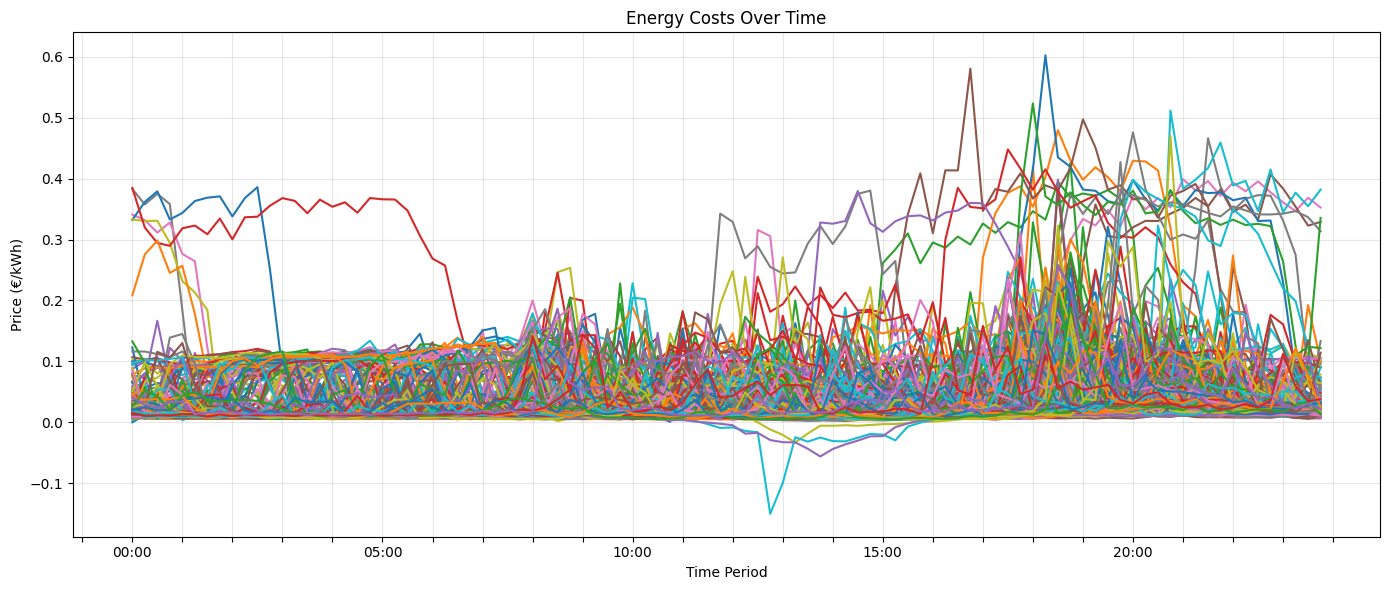

Energiekosten met dynamisch contract: € 1142.14, voordeel = € 97.54


In [ ]:
def multiply_tables_by_column(consumptionTable: pd.DataFrame, priceTable: pd.DataFrame) -> pd.DataFrame:
    shared_columns = [
        col for col in consumptionTable.columns
        if col.lower() not in EXCLUDED_COLUMNS and col in priceTable.columns
    ]
    consumption_numeric = consumptionTable[shared_columns].apply(pd.to_numeric, errors="coerce")
    prices_numeric = priceTable[shared_columns].apply(pd.to_numeric, errors="coerce")
    consumption_numeric = consumption_numeric.mul(prices_numeric)
    return consumption_numeric

resultTable = multiply_tables_by_column(predictedEnergyConsumption, energyPrices)

plot_dataframe(
    resultTable, 
    # resultTable[energyPrices['date'] == '2025-11-12'],
    # resultTable[resultTable['date'] == '2025-11-13'],
    # resultTable[resultTable['date'] == '2025-11-14'],
    "Energy Costs Over Time", "Time Period", "Price (€/kWh)"
)

total_dyn_costs = sum_dataframe_values(resultTable)

print("Energiekosten met dynamisch contract: €", f"{total_dyn_costs:.2f}, voordeel = €", f"{totalCost - total_dyn_costs:.2f}")

## Berekenen energiekosten met dynamisch contract EN batterij


In [ ]:
#code
def calc_charge_strategy_per_day(row: pd.DataFrame) -> pd.DataFrame:
    numeric_row = pd.to_numeric(row, errors="coerce")
    charge_row = numeric_row.sort_values().index.tolist()
    # print(f"charge_row = {charge_row}")
    return charge_row

def calc_charge_strategy(prijzen_table: pd.DataFrame) -> pd.DataFrame:
    data_columns = [col for col in prijzen_table.columns if col.lower() not in EXCLUDED_COLUMNS]
    charge_table_rows = []

    for row_index, row in prijzen_table[data_columns].iterrows():
        charge_table_rows.append({
            "row_index": row_index,
            "sorted_price_columns": calc_charge_strategy_per_day(row),
        })
    # row_index = 1
    # print(f"Row {row_index}: sorted columns = {charge_table_rows[row_index]['sorted_price_columns']}")  
    # plot_dataframe(
    #     charge_table_rows,
    #     "Battery Charge Strategy", "Time Period", "Battery Charge (kWh)"
    #     )
    return pd.DataFrame(charge_table_rows)

def calc_discharge_strategy_per_day(row: pd.DataFrame) -> pd.DataFrame:
    numeric_row = pd.to_numeric(row, errors="coerce")
    discharge_row = numeric_row.sort_values(ascending=False).index.tolist()
    # print(f"discharge_row = {discharge_row}")
    return discharge_row

def calc_discharge_strategy(prijzen_table: pd.DataFrame) -> pd.DataFrame:
    data_columns = [col for col in prijzen_table.columns if col.lower() not in EXCLUDED_COLUMNS]
    discharge_table_rows = []

    for row_index, row in prijzen_table[data_columns].iterrows():
        discharge_table_rows.append({
            "row_index": row_index,
            "sorted_price_columns": calc_discharge_strategy_per_day(row),
        })
    # row_index = 1
    # print(f"Row {row_index}: sorted columns = {discharge_table_rows[row_index]['sorted_price_columns']}")  
    return pd.DataFrame(discharge_table_rows)

def battery_charging_algorithm(
    energyConsumption: pd.DataFrame, 
    optimal_charge_timestamps: pd.DataFrame,
    optimal_discharge_timestamps: pd.DataFrame,
    max_charge_speed: float,
    max_battery_capacity: float,
    rte: float
) -> pd.DataFrame:
    energy_per_quarter = max_charge_speed / 4
    nrof_charge_intervals = max_battery_capacity / energy_per_quarter
    print(f"Battery capacity: {max_battery_capacity} kWh, charge speed: {max_charge_speed} kW")
    print(f"Number of charge intervals [15 min.]: {nrof_charge_intervals}, energy per interval: {energy_per_quarter} kWh")
    energyConsumption = energyConsumption.copy()
    batteryCharge = energyConsumption.copy()

    for row_index, row in energyConsumption.iterrows():
        # process charging    
        available_columns = optimal_charge_timestamps.loc[row_index, "sorted_price_columns"]
        battery_capacity = 0
        count = 0
        for col_name in available_columns:
            if count >= int(nrof_charge_intervals):
                charge = energy_per_quarter*(nrof_charge_intervals - count)
                energyConsumption.loc[row_index, col_name] += charge
                battery_capacity += charge
                batteryCharge.loc[row_index, col_name] = battery_capacity
                # print(f"count={count}, battery capacity now: {battery_capacity} kWh")
                break
            else:
                energyConsumption.loc[row_index, col_name] += energy_per_quarter
                battery_capacity += energy_per_quarter
                batteryCharge.loc[row_index, col_name] = battery_capacity
                count += 1

        # process discharging
        battery_capacity_remaining = battery_capacity * rte
        discharge_columns = optimal_discharge_timestamps.loc[row_index, "sorted_price_columns"]
        for col_name in discharge_columns:
            current_consumption = min(float(energyConsumption.loc[row_index, col_name]), energy_per_quarter)
            if battery_capacity_remaining >= current_consumption:
                energyConsumption.loc[row_index, col_name] -= current_consumption
                battery_capacity_remaining -= current_consumption
                batteryCharge.loc[row_index, col_name] = battery_capacity_remaining
            else:
                energyConsumption.loc[row_index, col_name] -= battery_capacity_remaining
                battery_capacity_remaining = 0
                batteryCharge.loc[row_index, col_name] = battery_capacity_remaining
                break   
        
    # Add total, average, min, and max for each row
    # numeric_columns = [col for col in energyConsumption.columns if col.lower() not in EXCLUDED_COLUMNS]
    # energyConsumption['date'] = energyPrices['date']
    # energyConsumption["total"] = energyConsumption[numeric_columns].sum(axis=1)
    # energyConsumption["average"] = energyConsumption[numeric_columns].mean(axis=1)
    # energyConsumption["minimum"] = energyConsumption[numeric_columns].min(axis=1)
    # energyConsumption["maximum"] = energyConsumption[numeric_columns].max(axis=1)

    # numeric_columns = [col for col in batteryCharge.columns if col.lower() not in EXCLUDED_COLUMNS]
    # batteryCharge['date'] = energyPrices['date']
    # batteryCharge["total"] = batteryCharge[numeric_columns].sum(axis=1)
    # batteryCharge["average"] = batteryCharge[numeric_columns].mean(axis=1)
    # batteryCharge["minimum"] = batteryCharge[numeric_columns].min(axis=1)
    # batteryCharge["maximum"] = batteryCharge[numeric_columns].max(axis=1)
    return energyConsumption, batteryCharge


# prep the battery charge algorithm, 
# calculate the optimal charge and discharge strategies based on the energy prices
charge_strategy = calc_charge_strategy(energyPrices)
discharge_strategy = calc_discharge_strategy(energyPrices)

# Run the battery charge algorithm
geoptimaliseerdVerbruikTable, batteryChargeStorageTable = battery_charging_algorithm(
    predictedEnergyConsumption, 
    charge_strategy,
    discharge_strategy,
    CHARGING_POWER,
    BATTERY_CAPACITY,
    RTE    
  );

batteryChargeStorageTable['date'] = energyPrices['date']
geoptimaliseerdVerbruikTable['date'] = energyPrices['date']

# print teable heads for debugging
# print(geoptimaliseerdVerbruikTable.head())
# print(batteryChargeStorageTable.head())

# save the tables to a CSV file
# geoptimaliseerdVerbruikTable.to_csv("geoptimaliseerdVerbruikTable.csv", index=False, float_format='%.4f')
# batteryChargeStorageTable.to_csv("batteryChargeStorageTable.csv", index=False, float_format='%.4f')

# calculate the cost table by multiplying the optimized consumption table with the prices table
costTable = multiply_tables_by_column(geoptimaliseerdVerbruikTable, energyPrices)
costTable['date'] = energyPrices['date']
# print(costTable.head())


total_dyn_costs_smart = sum_dataframe_values(costTable)
print("Energiekosten met dynamisch contract en batterij: €", f"{total_dyn_costs_smart:.2f}, voordeel = €", f"{totalCost - total_dyn_costs_smart:.2f}")


Battery capacity: 6 kWh, charge speed: 0.8 kW
Number of charge intervals [15 min.]: 30.0, energy per interval: 0.2 kWh
Energiekosten met dynamisch contract en batterij: € 1025.25, voordeel = € 214.42


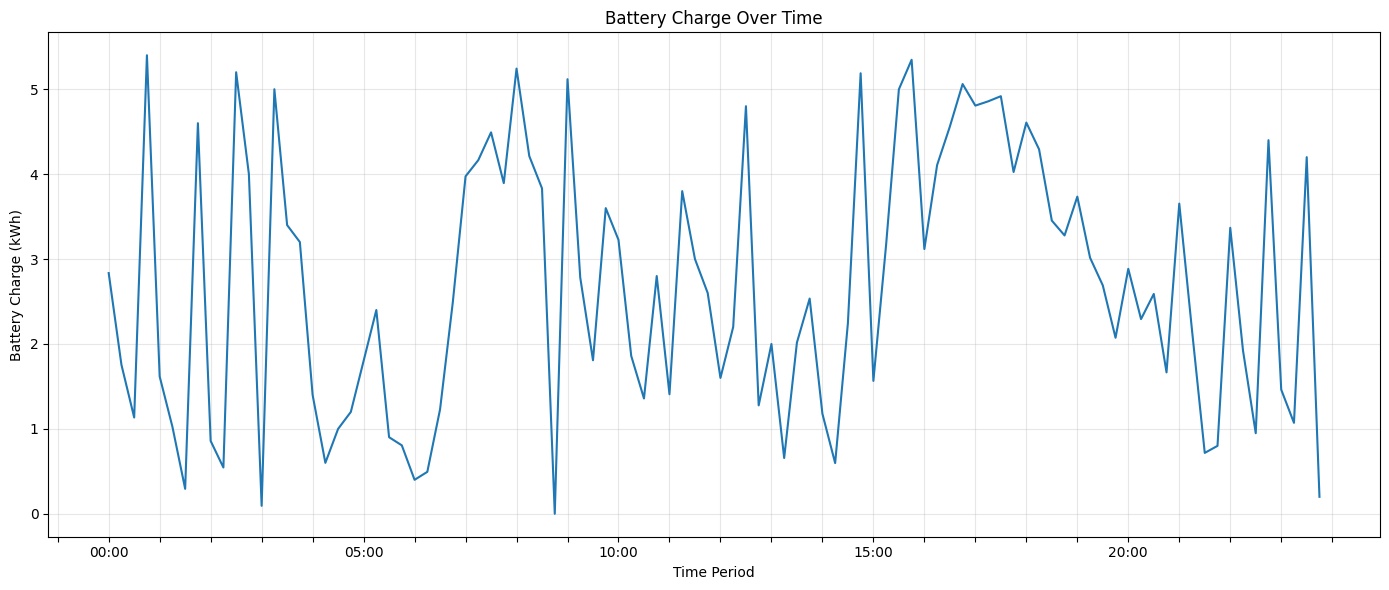

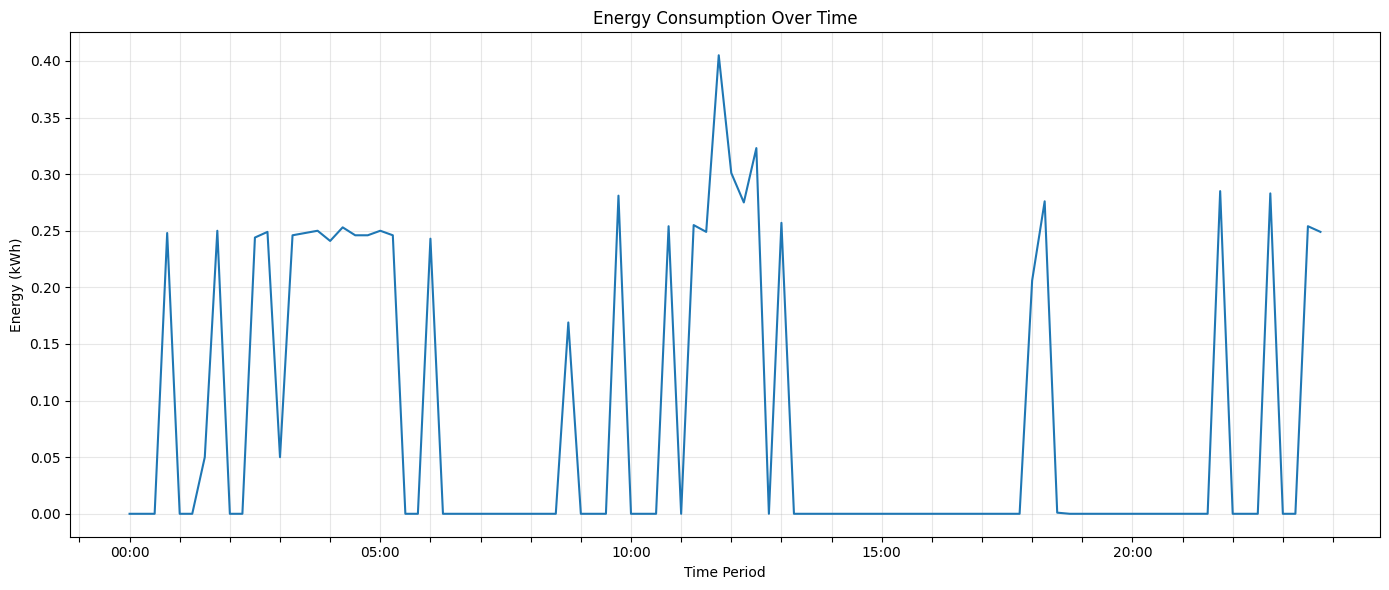

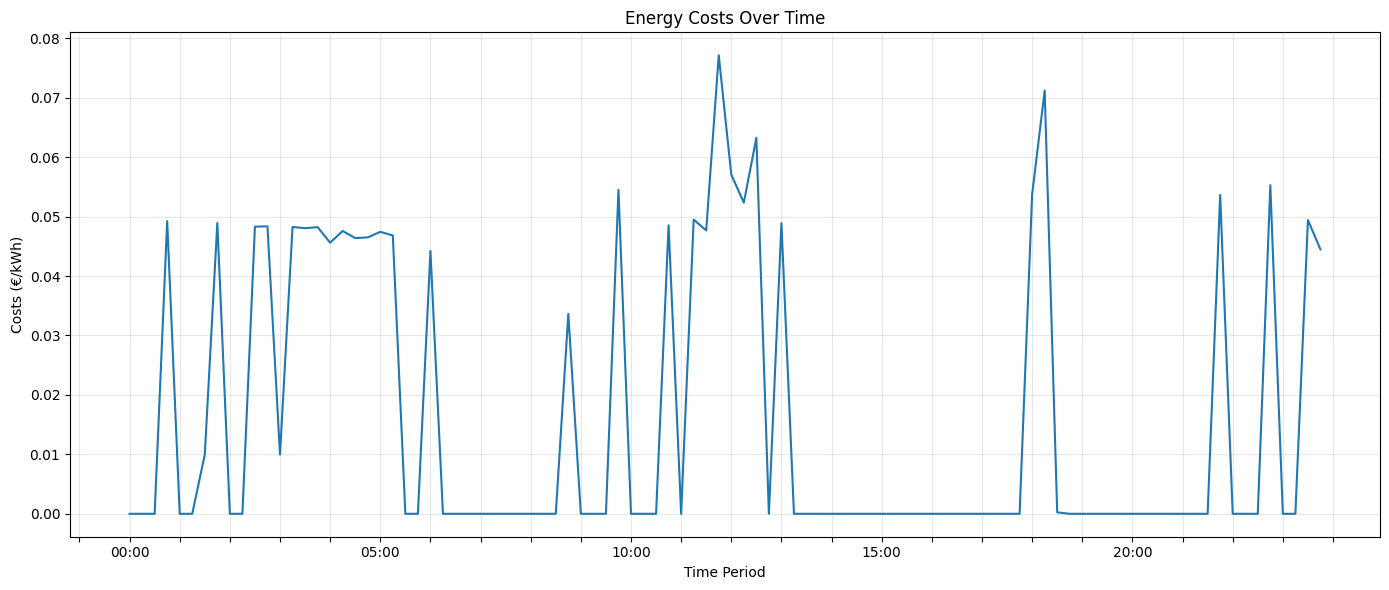

In [33]:
# plot the tables
plot_dataframe(
    # batteryChargeStorageTable,
    batteryChargeStorageTable[batteryChargeStorageTable['date'] == '2025-11-12'],
    # batteryChargeStorageTable[batteryChargeStorageTable['date'] == '2025-11-13'],
    # batteryChargeStorageTable[batteryChargeStorageTable['date'] == '2025-11-14'],
    "Battery Charge Over Time", "Time Period", "Battery Charge (kWh)"
)

plot_dataframe(
    # geoptimaliseerdVerbruikTable, 
    geoptimaliseerdVerbruikTable[geoptimaliseerdVerbruikTable['date'] == '2025-11-12'],
    # geoptimaliseerdVerbruikTable[geoptimaliseerdVerbruikTable['date'] == '2025-11-13'],
    # geoptimaliseerdVerbruikTable[geoptimaliseerdVerbruikTable['date'] == '2025-11-14'],
    "Energy Consumption Over Time", "Time Period", "Energy (kWh)"
)

plot_dataframe(
    # costTable,
    costTable[costTable['date'] == '2025-11-12'],
    # costTable[costTable['date'] == '2025-11-13'],
    # costTable[costTable['date'] == '2025-11-14'],   
    "Energy Costs Over Time", "Time Period", "Costs (€/kWh)"
)

In [32]:

print("Energie gebruik:", totalEnergieUsage, "[kWh]")
print("Energie prijs:", KWH_PRICE, "[€/kWh]")
print("Energiekosten met vast contract: €", f"{totalCost:.2f}")
print("Energiekosten met dynamisch contract: €", f"{total_dyn_costs:.2f}, voordeel = €", f"{totalCost - total_dyn_costs:.2f}") 

print("Energiekosten met dynamisch contract en batterij: €", f"{total_dyn_costs_smart:.2f}, voordeel = €", f"{totalCost - total_dyn_costs_smart:.2f}")
print("Batterij capaciteit:", BATTERY_CAPACITY, "[kWh]")
print("Batterij laadvermogen:", CHARGING_POWER, "[kW]")
print("Batterij prijs:", BATTERY_PRICE, "[€]")
print("Batterijvoordeel: €", f"{total_dyn_costs - total_dyn_costs_smart:.2f}")
print("Batterij terugverdientijd:", BATTERY_PRICE / (total_dyn_costs - total_dyn_costs_smart), "[jaar]")

Energie gebruik: 4591.392 [kWh]
Energie prijs: 0.27 [€/kWh]
Energiekosten met vast contract: € 1239.68
Energiekosten met dynamisch contract: € 1142.14, voordeel = € 97.54
Energiekosten met dynamisch contract en batterij: € 1025.25, voordeel = € 214.42
Batterij capaciteit: 6 [kWh]
Batterij laadvermogen: 0.8 [kW]
Batterij prijs: 3250 [€]
Batterijvoordeel: € 116.88
Batterij terugverdientijd: 27.806028545925958 [jaar]
